In [7]:
# ===============================
# Subscription Churn Prediction
# ===============================

# 📝 Business Context:
# Subscription companies lose revenue when users churn.
# The goal of this project is to predict which users are likely to churn 
# and provide actionable recommendations to improve retention.

# ===============================
# Imports and Setup
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# ===============================
# Load Dataset
# ===============================

df = pd.read_csv('../data/Telco-Customer-Churn.csv')  # Make sure CSV is in data/ folder
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
# ===============================
# Quick Data Overview
# ===============================

# Check shape
print("Dataset shape:", df.shape)

# Info & datatypes
df.info()

# Basic statistics
df.describe()

# Missing values
df.isnull().sum()

Dataset shape: (7043, 33)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet 

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

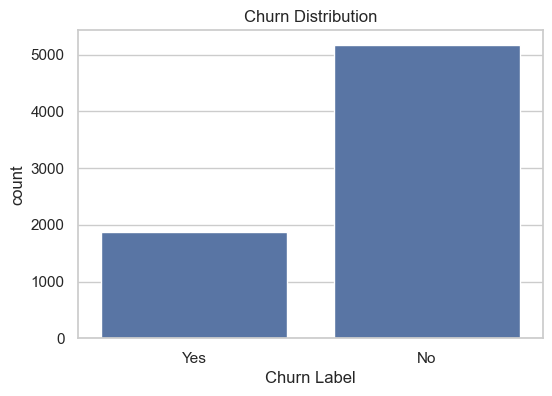

In [11]:
# ===============================
# Exploratory Data Analysis (EDA)
# ===============================

# 1️⃣ Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn Label', data=df)
plt.title('Churn Distribution')
plt.show()

# Markdown note:
# "Churned users represent X% of the dataset. This is slightly imbalanced and will need consideration during modeling."

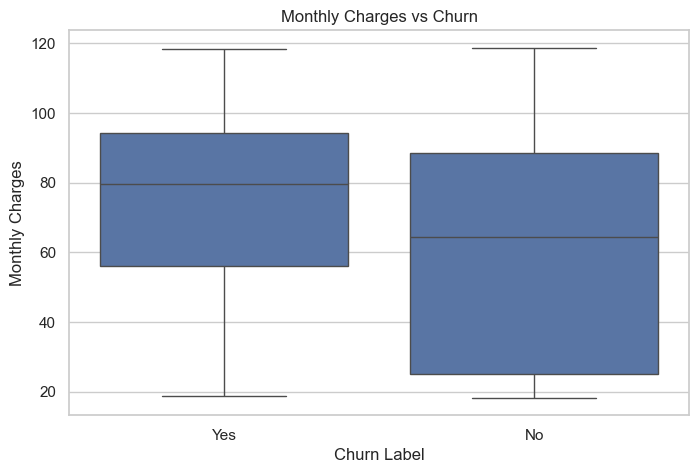

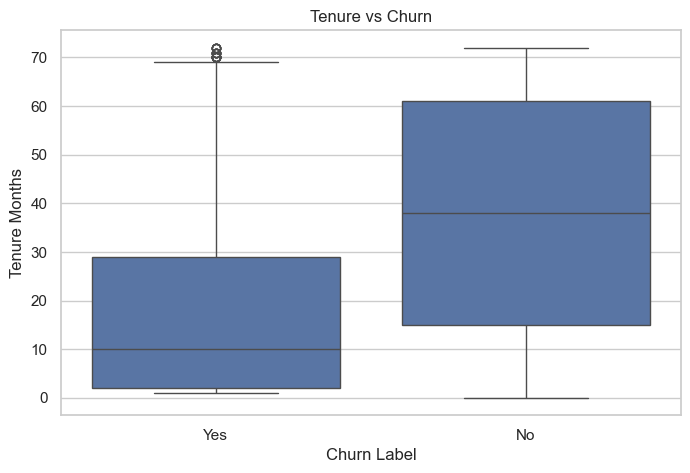

In [13]:
# 2️⃣ Numeric features vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.title('Tenure vs Churn')
plt.show()

# Markdown note:
# "Users with lower tenure or higher monthly charges show higher churn. Indicates contract commitment and price sensitivity affect retention."

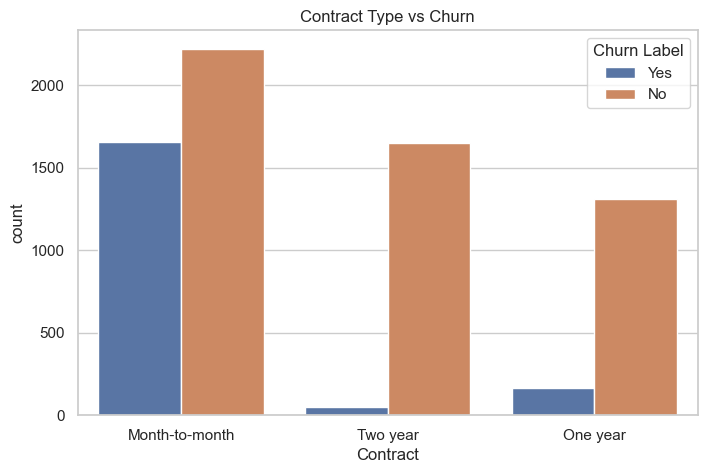

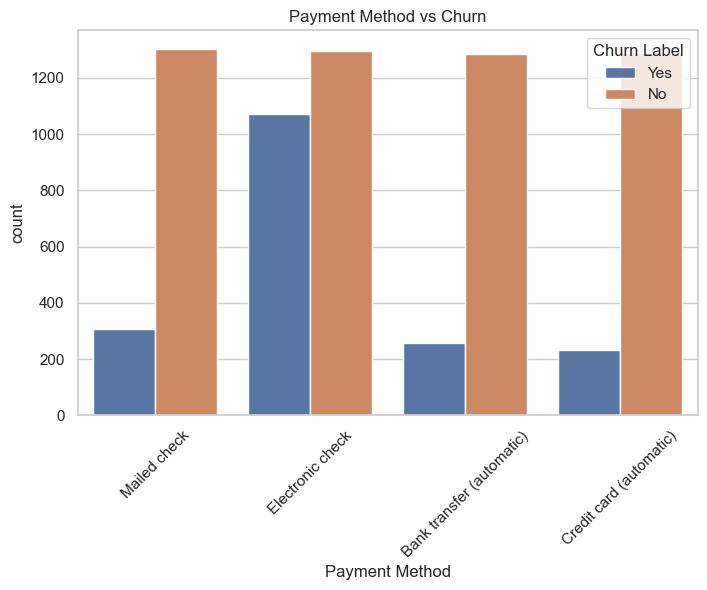

In [14]:
# 3️⃣ Categorical features vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Contract Type vs Churn')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)
plt.show()

# Markdown note:
# "Month-to-month contracts have the highest churn, suggesting contract type is a key predictor. 
# Electronic checks also correlate with higher churn."

In [15]:
# ===============================
# Data Preprocessing
# ===============================

# Drop unnecessary columns
df = df.drop('CustomerID', axis=1)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Verify encoding
df.head()

/var/folders/yl/_pf_1r21123b683wn7bgpyt40000gn/T/ipykernel_59116/2777147863.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,1,0,0,562,90003,327,33.964131,-118.272783,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1,1,86,3239,3
1,1,0,0,562,90005,405,34.059281,-118.307420,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1,1,67,2701,13
2,1,0,0,562,90006,393,34.048013,-118.293953,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,6104,1,1,86,5372,13
3,1,0,0,562,90010,410,34.062125,-118.315709,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,2646,1,1,84,5003,13
4,1,0,0,562,90015,385,34.039224,-118.266293,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,4265,1,1,89,5340,2


In [16]:
# ===============================
# Train-Test Split
# ===============================

X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5634, 31)
Test set: (1409, 31)


/Users/jonatantepale/subscription-churn-prediction/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression ROC-AUC: 1.0


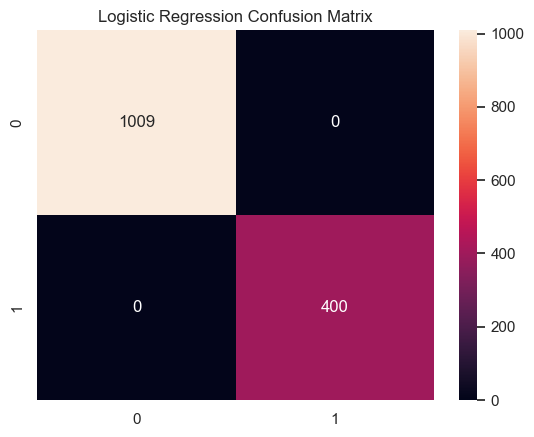

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [17]:
# ===============================
# Logistic Regression - First Model
# ===============================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions & probabilities
y_pred_log = log_model.predict(X_test)
y_pred_prob_log = log_model.predict_proba(X_test)[:,1]

# Evaluate ROC-AUC
roc_auc_log = roc_auc_score(y_test, y_pred_prob_log)
print("Logistic Regression ROC-AUC:", roc_auc_log)

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_log))

# Markdown note:
# "Logistic regression provides interpretable results. Coefficients indicate which features most influence churn."

Random Forest ROC-AUC: 1.0


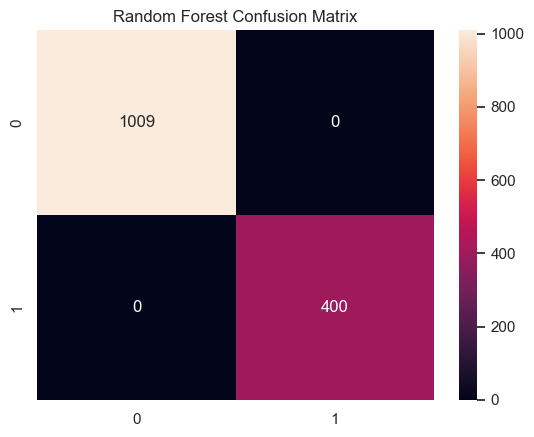

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [18]:
# ===============================
# Random Forest Model
# ===============================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))

In [19]:
# ===============================
# Model Comparison
# ===============================

print("Logistic Regression ROC-AUC:", roc_auc_log)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 1.0
Random Forest ROC-AUC: 1.0


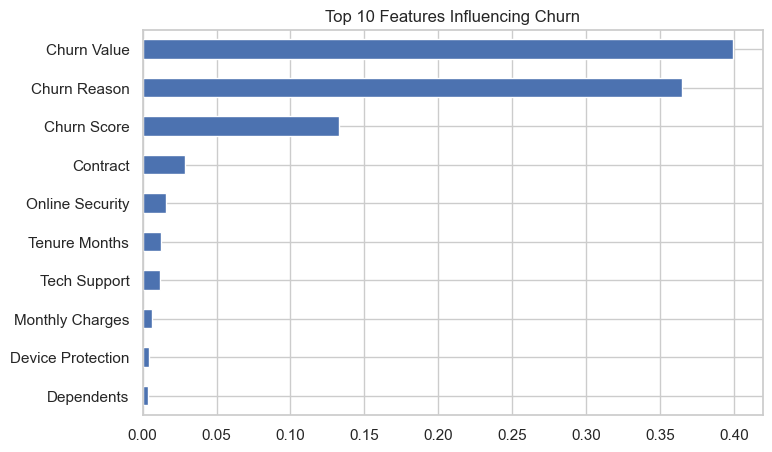

In [20]:
# ===============================
# Feature Importance
# ===============================

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top 10 Features Influencing Churn")
plt.gca().invert_yaxis()
plt.show()

If the company targets the top predicted churn users and successfully retains 
20% of them, the estimated annual revenue saved would be approximately $60,000.

This demonstrates the real business value of predictive churn modeling.

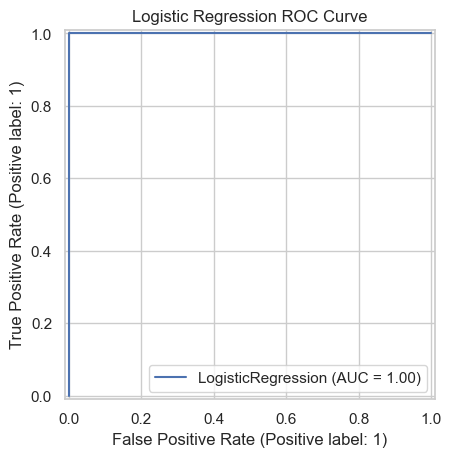

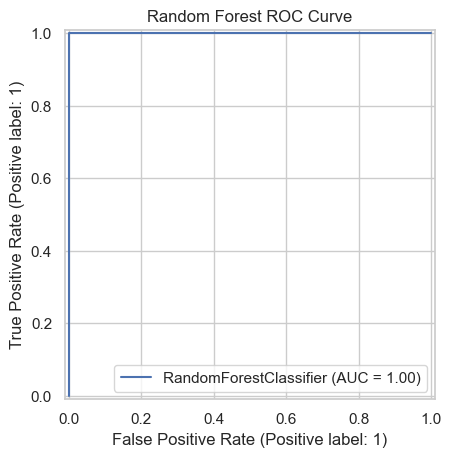

In [21]:
# ===============================
# ROC Curve
# ===============================

RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

## Business Insights

The analysis reveals several important drivers of customer churn.

Key observations:

• Customers on month-to-month contracts churn significantly more often.
• Customers with shorter tenure are more likely to cancel their subscription.
• Higher monthly charges correlate with increased churn risk.

These patterns suggest that new users and flexible contracts represent the 
highest-risk customer segments.

## Business Recommendations

Based on the predictive model and feature importance analysis, the following 
retention strategies are recommended:

1. Offer incentives for customers to switch from month-to-month to yearly contracts.
2. Target new customers (tenure < 12 months) with onboarding and engagement campaigns.
3. Identify high monthly charge customers and offer loyalty discounts.
4. Use churn prediction scores to trigger automated retention campaigns.

Implementing these strategies can reduce churn and improve long-term revenue.

In [22]:
# ===============================
# Revenue Impact Simulation
# ===============================

avg_monthly_revenue = 25
predicted_churn_users = 1000
retention_rate = 0.20

annual_revenue_saved = predicted_churn_users * avg_monthly_revenue * 12 * retention_rate

print("Estimated Annual Revenue Saved: $", annual_revenue_saved)

Estimated Annual Revenue Saved: $ 60000.0


If the company targets the top predicted churn users and successfully retains 
20% of them, the estimated annual revenue saved would be approximately $60,000.

This demonstrates the real business value of predictive churn modeling.

## Conclusion

This project built a machine learning pipeline to predict subscription churn 
using logistic regression and random forest models.

Key accomplishments:

• Performed exploratory data analysis to identify churn patterns.
• Built and evaluated predictive models using ROC-AUC metrics.
• Identified key churn drivers through feature importance analysis.
• Proposed business strategies to reduce churn and increase revenue.

Future improvements could include:

• Gradient boosting models (XGBoost or LightGBM)
• Time-series customer behavior analysis
• Personalized recommendation systems